In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import my_extension


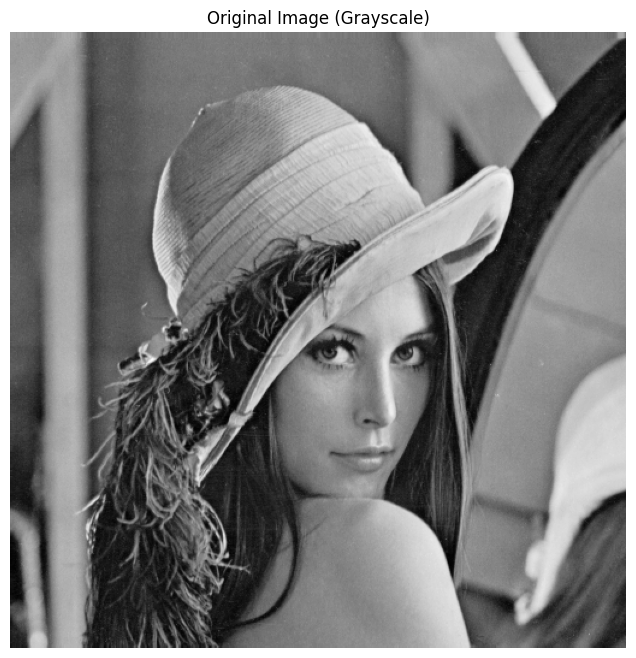

In [6]:
# Load image and convert to grayscale
img = Image.open('sample.jpg').convert('L')
# Convert to float32 numpy array
img_arr = np.array(img, dtype=np.float32)
m, n = img_arr.shape

plt.figure(figsize=(8, 8))
plt.imshow(img_arr, cmap='gray')
plt.title('Original Image (Grayscale)')
plt.axis('off')
plt.show()


In [8]:
# Helper function to apply filter and display the result
def apply_and_show(filter_obj, title):
    out = np.zeros((m, n), dtype=np.float32)
    filter_obj.apply(img_arr, out, m, n)
    
    plt.figure(figsize=(8, 8))
    # For derivative filters, we might have negative values, 
    # but matplotlib's imshow with cmap='gray' auto-scales min to max, 
    # making visualization easy.
    plt.imshow(out, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()
    return out


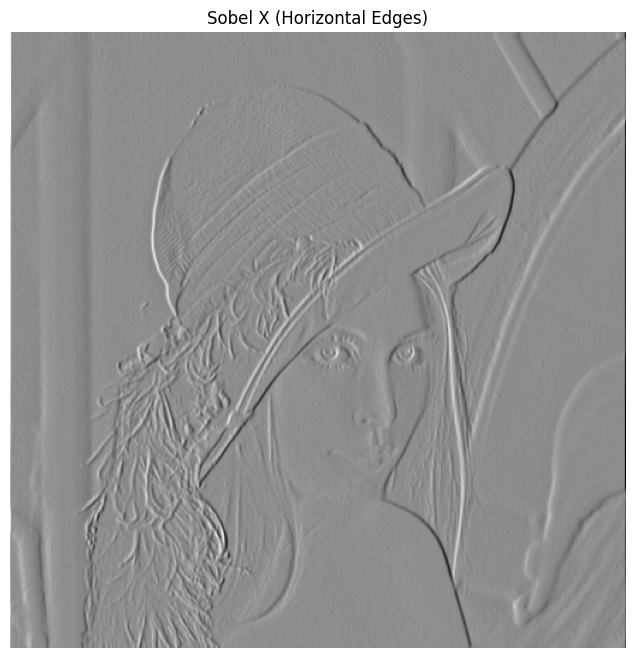

In [4]:
sobel_x = my_extension.SobelFilter('x')
out_sx = apply_and_show(sobel_x, 'Sobel X (Horizontal Edges)')


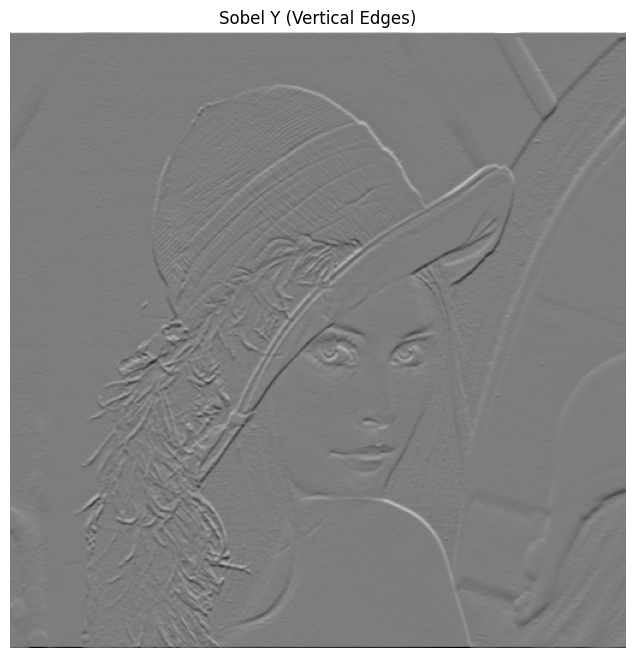

In [5]:
sobel_y = my_extension.SobelFilter('y')
out_sy = apply_and_show(sobel_y, 'Sobel Y (Vertical Edges)')


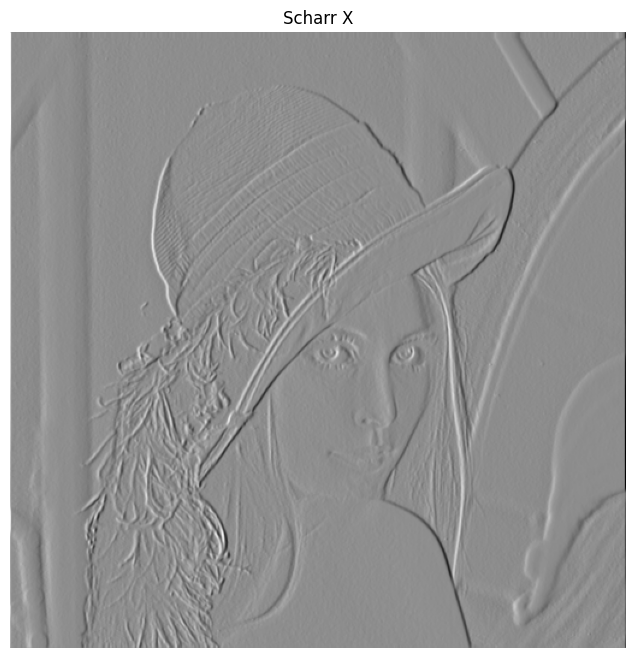

In [7]:
scharr_x = my_extension.ScharrFilter('x')
out_schx = apply_and_show(scharr_x, 'Scharr X')


In [ ]:
lap4 = my_extension.LaplacianFilter(4)
out_l4 = apply_and_show(lap4, 'Laplacian (4-connected)')


In [ ]:
lap8 = my_extension.LaplacianFilter(8)
out_l8 = apply_and_show(lap8, 'Laplacian (8-connected)')


In [ ]:
gauss3 = my_extension.GaussianBlur(3, 1.0)
out_g3 = apply_and_show(gauss3, 'Gaussian Blur (3x3, sigma=1.0)')


In [ ]:
gauss7 = my_extension.GaussianBlur(7, 2.0)
out_g7 = apply_and_show(gauss7, 'Gaussian Blur (7x7, sigma=2.0)')


In [ ]:
otsu = my_extension.OtsuBinarizer()
out_otsu = apply_and_show(otsu, 'Otsu Binarization')


In [ ]:
# RGB to HSV Conversion
img_rgb = Image.open('sample.jpg').convert('RGB')
img_rgb_arr = np.array(img_rgb, dtype=np.float32)
m_rgb, n_rgb, c = img_rgb_arr.shape

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb_arr.astype(np.uint8))
plt.title('Original Image (RGB)')
plt.axis('off')
plt.show()

rgb2hsv = my_extension.RGB2HSVConverter()
out_hsv = np.zeros_like(img_rgb_arr)
rgb2hsv.apply(img_rgb_arr, out_hsv, m_rgb, n_rgb)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
ax1.imshow(out_hsv[:,:,0], cmap='hsv')
ax1.set_title('Hue')
ax1.axis('off')
ax2.imshow(out_hsv[:,:,1], cmap='gray')
ax2.set_title('Saturation')
ax2.axis('off')
ax3.imshow(out_hsv[:,:,2], cmap='gray')
ax3.set_title('Value')
ax3.axis('off')
plt.show()
